# 01 - Photodetector / APD / SNR / Bandwidth Simulation

This notebook models an optical detector signal chain from photons to current,
then adds the dominant current-noise sources used in photonics test, optical
sensing, laser diagnostics, and imaging front-end design.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import plotting

plotting.set_style()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from src import noise
from src.detector import PhotodetectorParams, photodetector_noise_budget

## 1. Engineering Problem

Design a detector front end that can measure weak optical signals while keeping
enough bandwidth for the application. The practical questions are:

- What photocurrent is produced by a given optical power?
- Which noise source dominates at low, medium, and high power?
- How much optical power is needed for a target SNR?
- How does electrical bandwidth trade against SNR?
- Where does saturation invalidate the linear detector model?

## 2. Physical Assumptions

- Responsivity follows `R = eta q lambda / (h c)` before avalanche gain.
- Photocurrent is linear in optical power until front-end saturation.
- Shot, thermal, dark-current, and read-noise terms are independent RMS currents.
- The electrical noise bandwidth is approximated by the measurement bandwidth.
- APD gain multiplies signal current, while avalanche excess noise is represented
  by an excess-noise factor `F`.
- Saturation is modeled with a smooth current clamp to show the failure regime.

## 3. System Parameters

The values below are representative of a fast silicon detector or APD readout.
They are not tied to a specific vendor part; the point is to expose the scaling
laws that drive detector selection and front-end design.

In [2]:
params = PhotodetectorParams(
    wavelength_m=850e-9,
    quantum_efficiency=0.78,
    bandwidth_hz=20e6,
    load_resistance_ohm=1_000.0,
    temperature_k=300.0,
    dark_current_a=2e-9,
    read_noise_current_a=0.25e-9,
    saturation_current_a=1.5e-3,
    apd_gain=1.0,
    apd_excess_noise_factor=1.0,
)

pd.DataFrame(
    [
        ("wavelength_m", params.wavelength_m, "m", "Operating wavelength; sets photon energy and responsivity."),
        ("quantum_efficiency", params.quantum_efficiency, "fraction", "Fraction of incident photons producing collected carriers."),
        ("bandwidth_hz", params.bandwidth_hz, "Hz", "Equivalent electrical noise bandwidth of the receiver."),
        ("load_resistance_ohm", params.load_resistance_ohm, "ohm", "Transimpedance/load resistance setting Johnson current noise."),
        ("temperature_k", params.temperature_k, "K", "Physical temperature for thermal noise."),
        ("dark_current_a", params.dark_current_a, "A", "Leakage current contributing shot noise."),
        ("read_noise_current_a", params.read_noise_current_a, "A RMS", "Input-referred electronics/readout noise."),
        ("saturation_current_a", params.saturation_current_a, "A", "Soft current limit of detector or amplifier."),
        ("apd_gain", params.apd_gain, "x", "Avalanche gain; 1.0 means PIN diode mode."),
    ],
    columns=["parameter", "value", "unit", "engineering meaning"],
)

,parameter,value,unit,engineering meaning
0,wavelength_m,8.500000e-07,m,Operating wavelength; sets photon energy and r...
1,quantum_efficiency,7.800000e-01,fraction,Fraction of incident photons producing collect...
2,bandwidth_hz,2.000000e+07,Hz,Equivalent electrical noise bandwidth of the r...
3,load_resistance_ohm,1.000000e+03,ohm,Transimpedance/load resistance setting Johnson...
4,temperature_k,3.000000e+02,K,Physical temperature for thermal noise.
5,dark_current_a,2.000000e-09,A,Leakage current contributing shot noise.
6,read_noise_current_a,2.500000e-10,A RMS,Input-referred electronics/readout noise.
7,saturation_current_a,1.500000e-03,A,Soft current limit of detector or amplifier.
8,apd_gain,1.000000e+00,x,Avalanche gain; 1.0 means PIN diode mode.


## 4. Simulation Model

The first conversion is optical power to photocurrent:

`I_ph = R P_opt`, where `R = eta q lambda / (h c)`.

Longer wavelength photons carry less energy, so the same quantum efficiency gives
higher A/W responsivity at longer wavelength until the material bandgap cuts off.

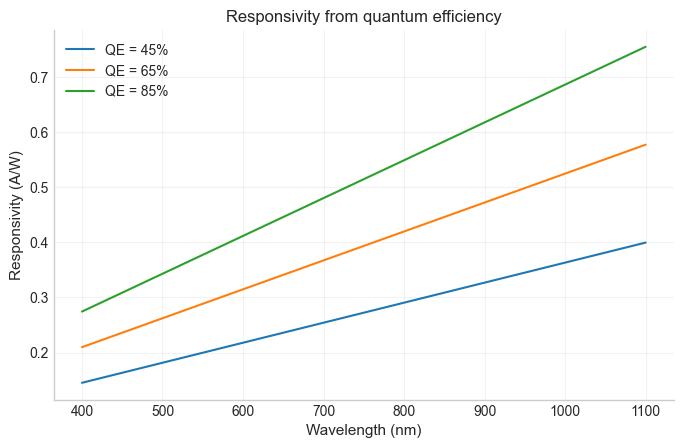

In [3]:
wavelength_nm = np.linspace(400, 1_100, 300)
qe_values = [0.45, 0.65, 0.85]

fig, ax = plt.subplots()
for qe in qe_values:
    ax.plot(
        wavelength_nm,
        noise.responsivity_from_qe(wavelength_nm * 1e-9, qe),
        label=f"QE = {qe:.0%}",
    )
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Responsivity (A/W)")
ax.set_title("Responsivity from quantum efficiency")
ax.legend()
plotting.save_figure(fig, FIG_DIR / "01_responsivity_vs_wavelength.png")
plt.show()

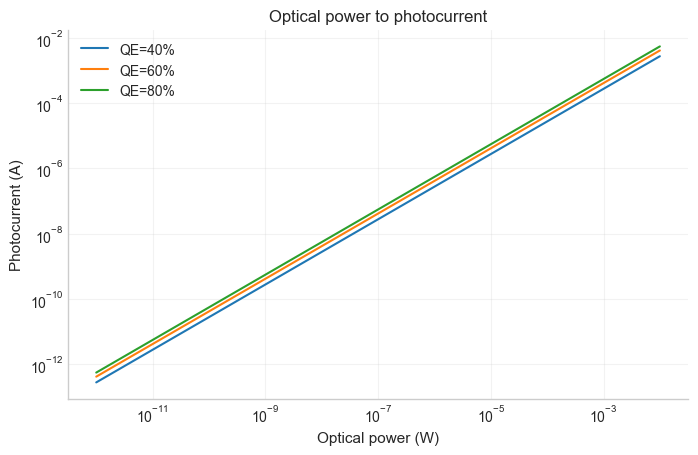

In [4]:
power_w = np.logspace(-12, -2, 500)
qe_scan = [0.4, 0.6, 0.8]

fig, ax = plt.subplots()
for qe in qe_scan:
    r = noise.responsivity_from_qe(params.wavelength_m, qe)
    ax.loglog(power_w, noise.optical_power_to_photocurrent(power_w, r), label=f"QE={qe:.0%}")
ax.set_xlabel("Optical power (W)")
ax.set_ylabel("Photocurrent (A)")
ax.set_title("Optical power to photocurrent")
ax.legend()
plt.show()

## 5. Noise / Uncertainty Model

The RMS current-noise terms are:

- Shot noise: `i_shot = sqrt(2 q I B)`
- Thermal noise: `i_thermal = sqrt(4 k_B T B / R_L)`
- Dark-current noise: same shot-noise form using dark current
- Read/electronics noise: input-referred RMS current

Independent current noises add in quadrature:

`i_total = sqrt(i_shot^2 + i_thermal^2 + i_dark^2 + i_read^2)`.

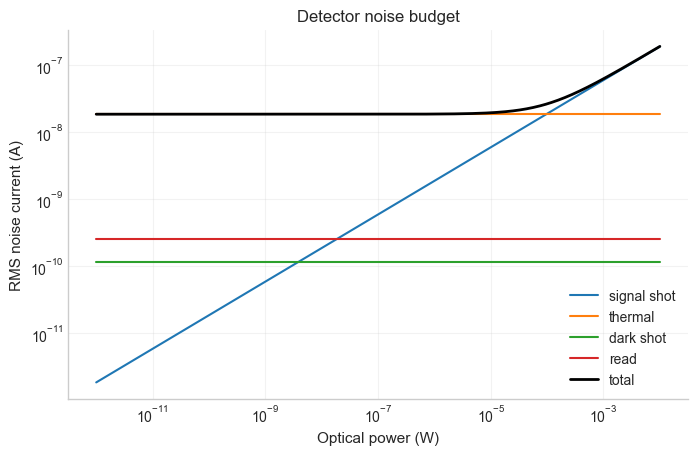

In [5]:
budget = photodetector_noise_budget(power_w, params)

fig, ax = plt.subplots()
ax.loglog(power_w, budget["shot_noise_current_a"], label="signal shot")
ax.loglog(power_w, budget["thermal_noise_current_a"], label="thermal")
ax.loglog(power_w, budget["dark_noise_current_a"], label="dark shot")
ax.loglog(power_w, budget["read_noise_current_a"], label="read")
ax.loglog(power_w, budget["total_noise_current_a"], "k", lw=2, label="total")
ax.set_xlabel("Optical power (W)")
ax.set_ylabel("RMS noise current (A)")
ax.set_title("Detector noise budget")
ax.legend()
plotting.save_figure(fig, FIG_DIR / "01_noise_budget.png")
plt.show()

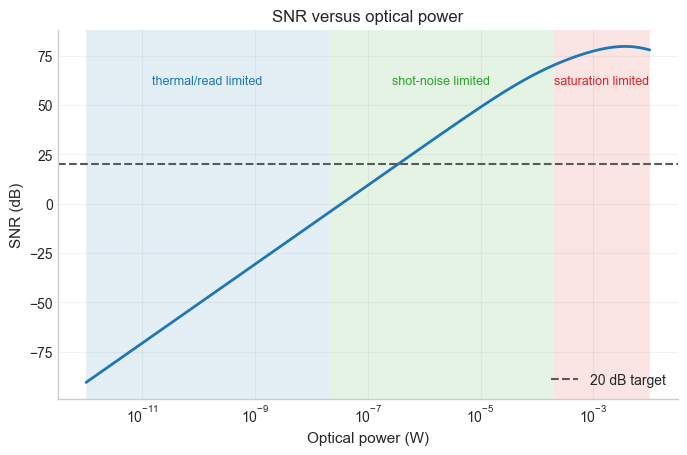

In [6]:
fig, ax = plt.subplots()
ax.semilogx(power_w, budget["snr_db"], lw=2)
ax.axhline(20, color="0.35", ls="--", label="20 dB target")
ax.set_xlabel("Optical power (W)")
ax.set_ylabel("SNR (dB)")
ax.set_title("SNR versus optical power")
plotting.add_regime_spans(
    ax,
    [
        (1e-12, 2e-8, "thermal/read limited", "tab:blue"),
        (2e-8, 2e-4, "shot-noise limited", "tab:green"),
        (2e-4, 1e-2, "saturation limited", "tab:red"),
    ],
)
ax.legend(loc="lower right")
plt.show()

## 6. Parameter Scan

Bandwidth is often the most painful detector trade-off. Increasing bandwidth
raises shot and thermal noise as `sqrt(B)`, so SNR drops even if optical power is
unchanged.

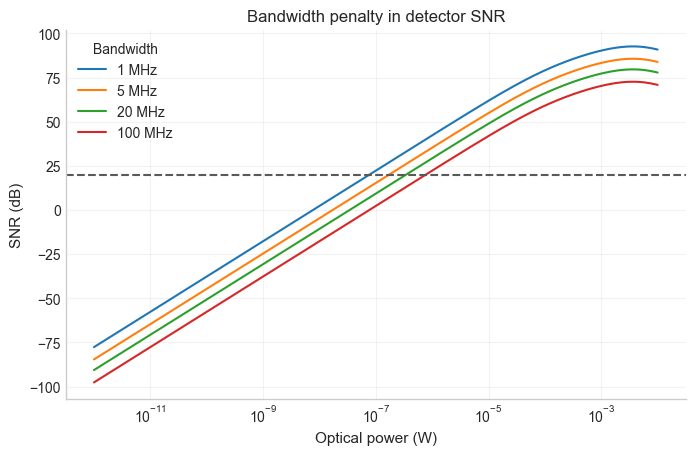

In [7]:
bandwidths = np.array([1e6, 5e6, 20e6, 100e6])
fig, ax = plt.subplots()
for bandwidth in bandwidths:
    p = PhotodetectorParams(**{**params.__dict__, "bandwidth_hz": bandwidth})
    b = photodetector_noise_budget(power_w, p)
    ax.semilogx(power_w, b["snr_db"], label=f"{bandwidth/1e6:g} MHz")
ax.axhline(20, color="0.35", ls="--")
ax.set_xlabel("Optical power (W)")
ax.set_ylabel("SNR (dB)")
ax.set_title("Bandwidth penalty in detector SNR")
ax.legend(title="Bandwidth")
plt.show()

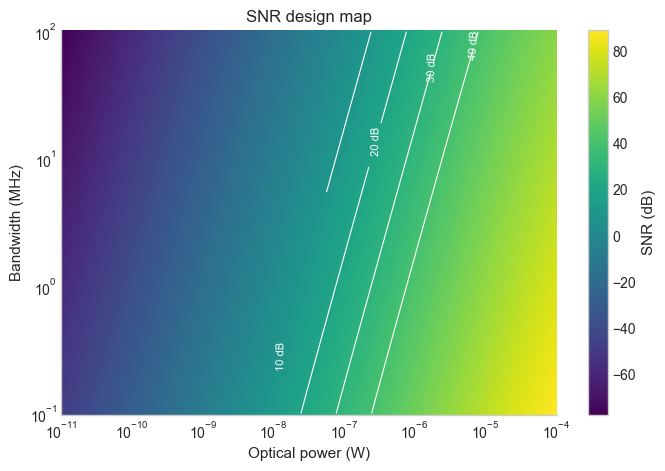

In [8]:
power_grid = np.logspace(-11, -4, 160)
bandwidth_grid = np.logspace(5, 8, 120)
snr_grid = np.empty((len(bandwidth_grid), len(power_grid)))

for i, bandwidth in enumerate(bandwidth_grid):
    p = PhotodetectorParams(**{**params.__dict__, "bandwidth_hz": bandwidth})
    snr_grid[i] = photodetector_noise_budget(power_grid, p)["snr_db"]

fig, ax = plt.subplots(figsize=(8, 5))
mesh = ax.pcolormesh(power_grid, bandwidth_grid / 1e6, snr_grid, shading="auto", cmap="viridis")
contours = ax.contour(power_grid, bandwidth_grid / 1e6, snr_grid, levels=[10, 20, 30, 40], colors="white", linewidths=0.8)
ax.clabel(contours, fmt="%d dB", fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Optical power (W)")
ax.set_ylabel("Bandwidth (MHz)")
ax.set_title("SNR design map")
fig.colorbar(mesh, ax=ax, label="SNR (dB)")
plt.show()

## 7. Failure Regime

Two failures matter in real measurements:

- Low-power failure: signal is below the noise floor, so SNR is below the target.
- High-power failure: the detector or transimpedance amplifier saturates, so the
  current no longer scales linearly with optical power.

In [9]:
rows = []
for bandwidth in bandwidths:
    p = PhotodetectorParams(**{**params.__dict__, "bandwidth_hz": bandwidth})
    b = photodetector_noise_budget(power_w, p)
    ok = b["snr_db"] >= 20
    p_min = power_w[np.argmax(ok)] if np.any(ok) else np.nan
    linearity = b["signal_current_a"] / np.maximum(b["ideal_output_signal_current_a"], 1e-30)
    below_90 = np.where(linearity < 0.9)[0]
    p_sat = power_w[below_90[0]] if len(below_90) else np.nan
    rows.append((bandwidth / 1e6, p_min, p_sat, p_sat / p_min))

pd.DataFrame(
    rows,
    columns=["bandwidth_MHz", "min_power_for_20dB_W", "power_at_10pct_compression_W", "usable_power_ratio"],
)

,bandwidth_MHz,min_power_for_20dB_W,power_at_10pct_compression_W,usable_power_ratio
0,1.0,7.758532e-08,0.000627,8087.524909
1,5.0,1.780332e-07,0.000627,3524.473004
2,20.0,3.557150e-07,0.000627,1763.977275
3,100.0,7.794416e-07,0.000627,805.029181


## 8. Design Trade-Off

APD gain can improve effective responsivity, but it does not create photons.
It also adds avalanche excess noise and reduces saturation headroom. The useful
question is not "maximum gain"; it is "gain at the required bandwidth before
noise and compression erase the benefit."

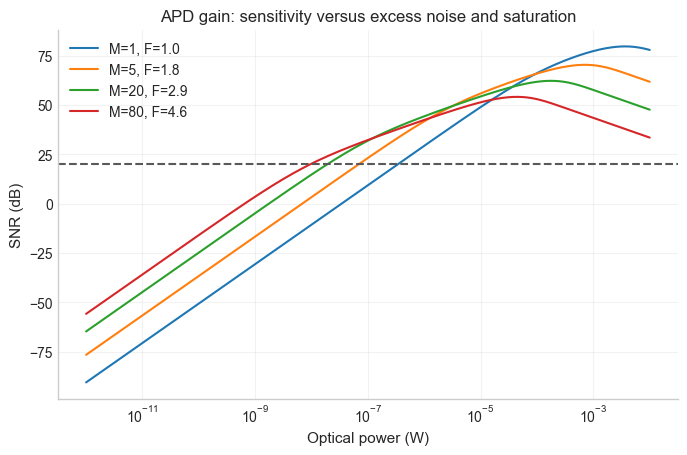

In [10]:
gains = [1, 5, 20, 80]
fig, ax = plt.subplots()
for gain in gains:
    excess = 1.0 if gain == 1 else gain**0.35
    p = PhotodetectorParams(
        **{
            **params.__dict__,
            "apd_gain": gain,
            "apd_excess_noise_factor": excess,
            "saturation_current_a": params.saturation_current_a,
        }
    )
    ax.semilogx(power_w, photodetector_noise_budget(power_w, p)["snr_db"], label=f"M={gain}, F={excess:.1f}")
ax.axhline(20, color="0.35", ls="--")
ax.set_xlabel("Optical power (W)")
ax.set_ylabel("SNR (dB)")
ax.set_title("APD gain: sensitivity versus excess noise and saturation")
ax.legend()
plt.show()

## 9. Key Engineering Conclusions

- Responsivity is set by both quantum efficiency and wavelength; quoting QE alone
  is not enough for system sensitivity.
- At very low optical power, thermal/read noise dominates and SNR improves almost
  linearly with power.
- In the shot-noise-limited region, signal rises as `P` while noise rises as
  `sqrt(P)`, so SNR improves as `sqrt(P)`.
- Wider bandwidth increases RMS noise as `sqrt(B)`, directly raising the minimum
  detectable optical power.
- Saturation creates a hard dynamic-range ceiling; once compressed, more optical
  power no longer gives a trustworthy measurement.
- APD gain is valuable only when the electronics noise floor is the bottleneck;
  excess noise and current compression limit the usable gain.